In [1]:
from sir.sir_scaled import model as sir_model
import matplotlib.pyplot as plt

from dyMES.model import model
import dyMES.rfunctions as rf
import numpy as np

# SIR

In [2]:
sir_model_obj = sir_model(0.33 / 100, 1/6, 100) # modified: see value of new_c0
sir_model_obj.simulate_sir(99, 1, 0, 14, 0.00001)

In [3]:
scaled_sir_vals = [i * sir_model_obj.G for i in sir_model_obj.sim_n]

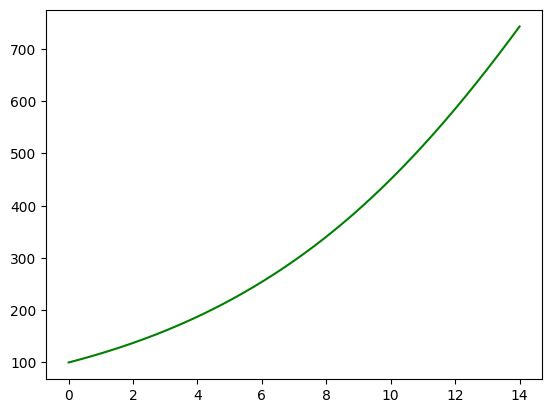

In [4]:
plt.plot(
    sir_model_obj.t,
    [scaled_sir_vals[j] for j in range(len(scaled_sir_vals))],
    label = "New SIR",
    color = 'green',
)

In [5]:
scaled_sir_dead = [r * sir_model_obj.G for r in sir_model_obj.sim_r]

In [6]:
scaled_sir_vals[-1], scaled_sir_dead[-1]

(np.float64(742.8683637204167), np.float64(788.6176954406853))

# DyMES infra

In [7]:
def pandemic_func(n, I, params):
    m_effective = (params['m_(t-1)'] - params['c1'] * params['tau'] * params['c0'] * params['m_(t-1)'] * params['<n>_(t-1)'])

    return (params['c0'] * params['h'] * n * np.exp(- 1 * I / params['K'])) * (m_effective - n) - (params['d_0'] * n)

In [8]:
def new_run_model_for_K(K, new_c0 = 0.006, tau = 0.00001, num_days = 7):
    # Instantiate params
    model_params = {
        'm_0': 100,
        'G': 100,
        'K': K,
        'd_0': 1/6,
        'c0': 0.006, # anlogous to r_0. originally 0.006
        'c1': 1,
        'c2': 1,
        'tau': tau,
        '<n>_(t-1)': 0,
        'm_(t-1)': 100, # should be set to the same value as m_0
        'h': 1,
    }
    initial_infected = 100

    pandemic_dymes = model(initial_infected, model_params, pandemic_func, 'G')

    pandemic_dymes.update_param('c0', pandemic_dymes.find_steady_state_params('c0'))
    print("Steady state c0:", pandemic_dymes.params['c0'])

    pandemic_dymes.update_param('c0', new_c0 / model_params['G'])
    print("Updated c0:", pandemic_dymes.params['c0'])
    pandemic_dymes.update(num_days, dt = tau)

    return pandemic_dymes

In [9]:
from dyMES.model_k_inf import model as model_k_inf

In [10]:
def pandemic_func_K_inf(n, I, params):
    m_effective = (params['m_(t-1)'] - params['c1'] * params['tau'] * params['c0'] * params['m_(t-1)'] * params['<n>_(t-1)'])

    return (params['c0'] * params['h'] * n * np.exp(0)) * (m_effective - n) - (params['d_0'] * n)

In [11]:
def new_run_model_for_K_inf(new_c0 = 0.006, tau = 0.00001, num_days = 7):
  # Instantiate params
  model_params = {
    'm_0': 100,
    'G': 100,
    # 'K': K,
    'd_0': 1/6,
    'c0': 0.006, # anlogous to r_0. originally 0.006
    'c1': 1,
    'c2': 1,
    'tau': tau,
    '<n>_(t-1)': 0,
    'm_(t-1)': 100, # should be set to the same value as m_0
    'h': 1,
  }
  initial_infected = 100

  pandemic_dymes = model_k_inf(initial_infected, model_params, pandemic_func_K_inf, 'G')

  pandemic_dymes.update_param('c0', pandemic_dymes.find_steady_state_params('c0'))
  print("Steady state c0:", pandemic_dymes.params['c0'])

  pandemic_dymes.update_param('c0', new_c0 / model_params['G'])
  print("Updated c0:", pandemic_dymes.params['c0'])
  pandemic_dymes.update(num_days, dt = tau)

  return pandemic_dymes

# Test DyMES

# K = 100

In [12]:
non_dec_c0_K_100 = new_run_model_for_K(100, new_c0 = 0.33, num_days = 14)

Steady state c0: 0.00467058755901267
Updated c0: 0.0033
1e-05
Error: 2.397715801983394e-16
0.999999510760539 [0.69314718 0.        ] 0.999999510760539 1.9999995107604998
Determinant: 6234.357326965518
Determinant: 6230.509494413628
Determinant: 6226.668955774218
Determinant: 6222.835694374946
Determinant: 6219.009693587561
Determinant: 6215.19093682767
Determinant: 6211.379407554639
Determinant: 6207.575089271565
Determinant: 6203.7779655249615
Determinant: 6199.988019904762
0.09999999999999393
Error: 2.350895767770929e-08
0.9951467025678314 [6.95582457e-01 7.93774620e-08] 0.9951467025678314 1.9951467021851428
Determinant: 6196.205236044139
Determinant: 6192.429597619438
Determinant: 6188.661088350039
Determinant: 6184.899691998226
Determinant: 6181.145392369061
Determinant: 6177.3981733102055
Determinant: 6173.658018711932
Determinant: 6169.924912506866
Determinant: 6166.198838670064
Determinant: 6162.47978121859
0.20000000000005924
Error: 9.24598744201114e-08
0.990370564323522 [6.979

In [13]:
non_dec_c0_K_100.states[7 * (10 ** 5) - 1]

np.float64(78.67613211046387)

In [14]:
non_dec_c0_K_100.states[-1]

np.float64(69.80206140050907)

In [15]:
non_dec_c0_K_100.num_dead[-1]

np.float64(188.1775466904997)

In [16]:
non_dec_c0_K_100.num_dead[7 * (10 ** 5) - 1]

np.float64(102.20953941575127)

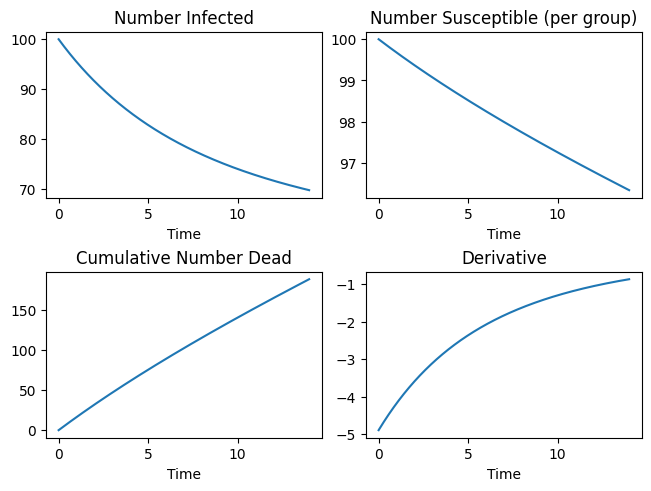

In [17]:
non_dec_c0_K_100.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.48842856 0.23856246 0.11652072 0.05691205 0.02779747
 0.01357708 0.00663143 0.00323898 0.00158201]
[1.         0.47807855 0.2285591  0.10926921 0.05223926 0.02497447
 0.01193976 0.00570814 0.00272894 0.00130465]
[1.         0.46881293 0.21978557 0.10303832 0.0483057  0.02264634
 0.0106169  0.00497734 0.00233344 0.00109395]
[1.00000000e+00 4.60507139e-01 2.12066827e-01 9.76582894e-02
 4.49723405e-02 2.07100845e-02 9.53714214e-03 4.39192225e-03
 2.02251166e-03 9.31381115e-04]
[1.00000000e+00 4.53049447e-01 2.05253804e-01 9.29901241e-02
 4.21291255e-02 1.90865778e-02 8.64716391e-03 3.91759305e-03
 1.77486349e-03 8.04100982e-04]
[1.00000000e+00 4.46340474e-01 1.99219821e-01 8.89198712e-02
 3.96885388e-02 1.77146020e-02 7.90674429e-03 3.52910023e-03
 1.57518039e-03 7.03066824e-04]
[1.00000000e+00 4.40292353e-01 1.93857358e-01 8.53539146e-02
 3.75806773e-02 1.65464857e-

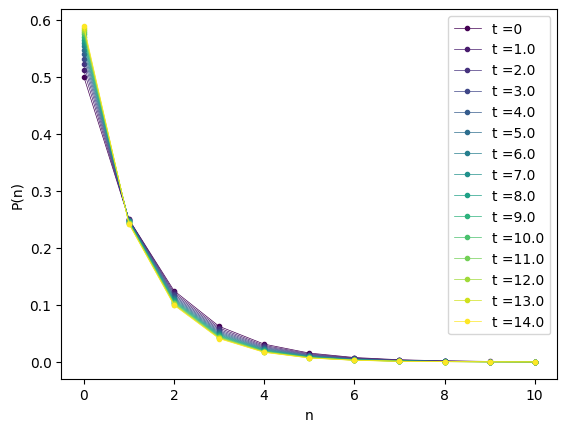

In [18]:
non_dec_c0_K_100.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 200

In [19]:
non_dec_c0_K_200 = new_run_model_for_K(200, new_c0 = 0.33, num_days = 14)

Steady state c0: 0.0028328544997431545
Updated c0: 0.0033
1e-05
Error: 1.120578221513287e-16
1.0000002749437664 [0.69314718 0.        ] 1.0000002749437664 2.000000274943746
Determinant: 5175.0442038600795
Determinant: 5177.383556050689
Determinant: 5179.721708851101
Determinant: 5182.058661525665
Determinant: 5184.394413341771
Determinant: 5186.72896357032
Determinant: 5189.062311485484
Determinant: 5191.394456364858
Determinant: 5193.725397489382
Determinant: 5196.055134143282
0.09999999999999393
Error: 1.109190203142562e-08
1.0027360275508377 [6.91782103e-01 2.46386447e-08] 1.0027360275508377 2.002736027352475
Determinant: 5198.383665614248
Determinant: 5200.710991193194
Determinant: 5203.037110174414
Determinant: 5205.362021855552
Determinant: 5207.68572553752
Determinant: 5210.008220524659
Determinant: 5212.329506124531
Determinant: 5214.649581648074
Determinant: 5216.968446409489
Determinant: 5219.286099726318
0.20000000000005924
Error: 4.391654245355793e-08
1.0054452675248375 [6.

In [20]:
non_dec_c0_K_200.states[7 * (10 ** 5) - 1]

np.float64(113.21473820053967)

In [21]:
non_dec_c0_K_200.states[-1]

np.float64(117.40085719706242)

In [22]:
non_dec_c0_K_200.num_dead[7 * (10 ** 5) - 1]

np.float64(125.48156217472159)

In [23]:
non_dec_c0_K_200.num_dead[-1]

np.float64(260.6586320373408)

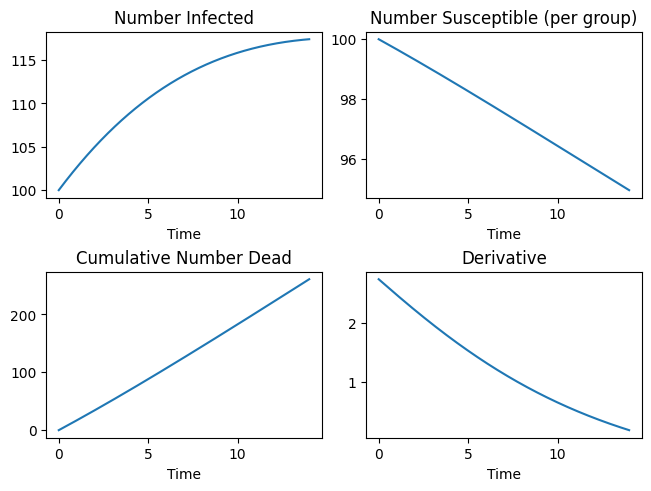

In [24]:
non_dec_c0_K_200.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.50645605 0.25649773 0.12990482 0.06579108 0.03332029
 0.01687526 0.00854658 0.00432847 0.00219218]
[1.         0.51212612 0.26227316 0.13431694 0.06878721 0.03522773
 0.01804104 0.00923929 0.00473168 0.00242322]
[1.         0.51708075 0.26737251 0.13825318 0.07148806 0.0369651
 0.01911394 0.00988345 0.00511054 0.00264256]
[1.         0.52138633 0.27184371 0.14173559 0.073899   0.03852993
 0.02008898 0.01047412 0.00546106 0.00284732]
[1.         0.5251044  0.27573463 0.14478947 0.07602959 0.03992347
 0.02096399 0.01100828 0.0057805  0.00303536]
[1.         0.5282918  0.27909223 0.14744214 0.07789247 0.04114995
 0.02173918 0.01148463 0.00606724 0.00320527]
[1.         0.53100065 0.28196169 0.14972184 0.07950239 0.04221582
 0.02241663 0.01190324 0.00632063 0.00335626]
[1.         0.53327834 0.28438579 0.15165679 0.08087528 0.04312904
 0.02299978 0.01226529 0.00654081

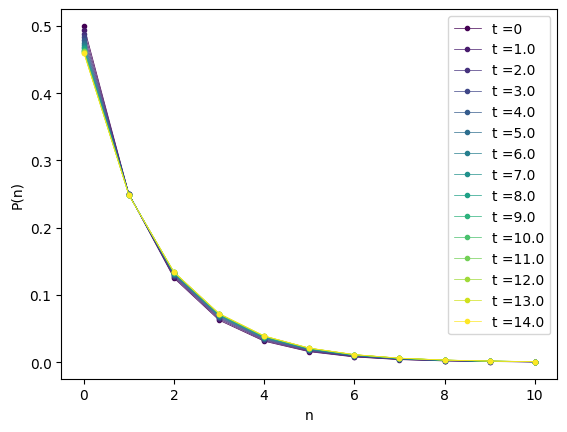

In [25]:
non_dec_c0_K_200.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 400

In [26]:
non_dec_c0_K_400 = new_run_model_for_K(400, new_c0 = 0.33, num_days = 14)

Steady state c0: 0.002206229288474961
Updated c0: 0.0033
1e-05
Error: 1.3216336442681953e-15
1.000000826638098 [0.69314718 0.        ] 1.000000826638098 2.0000008266378027
Determinant: 4464.861109742215
Determinant: 4469.704409053144
Determinant: 4474.550314590473
Determinant: 4479.398822591508
Determinant: 4484.249929285324
Determinant: 4489.103630892769
Determinant: 4493.959923626535
Determinant: 4498.818803691086
Determinant: 4503.680267282754
Determinant: 4508.544310589792
0.09999999999999393
Error: 1.3282469057431413e-07
1.008268261970864 [6.89038909e-01 2.86116168e-07] 1.008268261970864 2.008268258974238
Determinant: 4513.410929792276
Determinant: 4518.280121062116
Determinant: 4523.151880563222
Determinant: 4528.026204451347
Determinant: 4532.903088874222
Determinant: 4537.782529971504
Determinant: 4542.664523874819
Determinant: 4547.549066707801
Determinant: 4552.436154585846
Determinant: 4557.325783616931
0.20000000000005924
Error: 5.322815052410982e-07
1.0165396433115435 [6.8

In [27]:
non_dec_c0_K_400.states[7 * (10 ** 5) - 1]

np.float64(153.78996112444617)

In [28]:
non_dec_c0_K_400.states[-1]

np.float64(187.21201588493182)

In [29]:
non_dec_c0_K_400.num_dead[7 * (10 ** 5) - 1]

np.float64(149.27851470924824)

In [30]:
non_dec_c0_K_400.num_dead[-1]

np.float64(350.5743326260434)

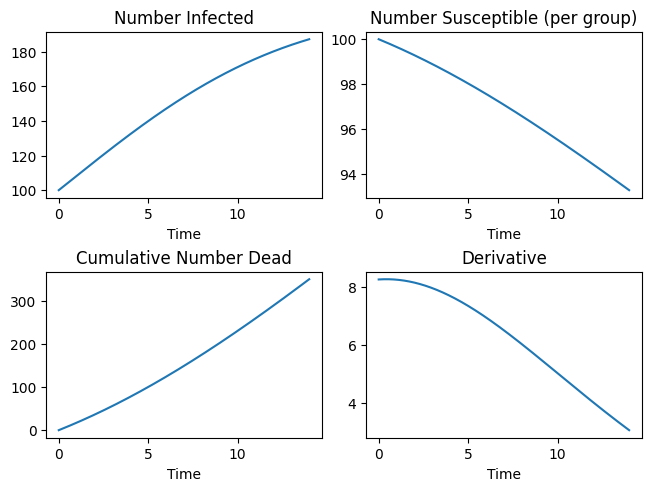

In [31]:
non_dec_c0_K_400.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.51985555 0.27024979 0.14049086 0.07303496 0.03796763
 0.01973768 0.01026075 0.00533411 0.00277296]
[1.         0.5380776  0.28952751 0.15578828 0.08382619 0.045105
 0.02426999 0.01305914 0.00702683 0.00378098]
[1.         0.55467608 0.30766556 0.17065474 0.09465811 0.0525046
 0.02912305 0.01615386 0.00896016 0.00496999]
[1.         0.56969409 0.32455137 0.18489502 0.10533361 0.06000795
 0.03418618 0.01947567 0.01109518 0.00632086]
[1.         0.58319857 0.34012059 0.19835787 0.11568204 0.06746562
 0.03934586 0.02294646 0.01338235 0.00780457]
[1.         0.5952738  0.35435092 0.21093584 0.1255646  0.07474534
 0.04449395 0.02648609 0.01576649 0.00938538]
[1.         0.60601341 0.36725227 0.22255983 0.13487427 0.08173564
 0.04953291 0.03001762 0.01819109 0.01102405]
[1.         0.61551637 0.37886042 0.23319482 0.14353526 0.08834833
 0.05437986 0.03347171 0.02060239 0

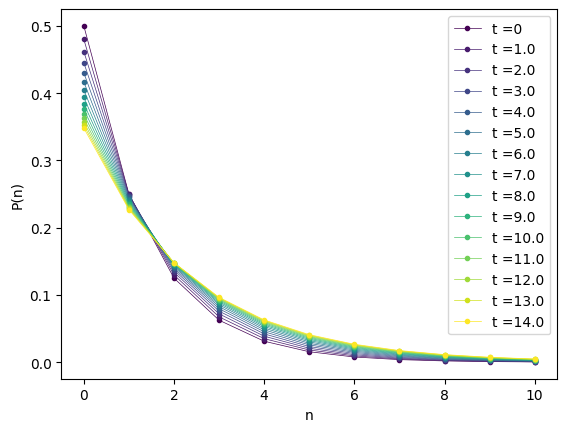

In [32]:
non_dec_c0_K_400.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 50

In [33]:
non_dec_c0_K_50 = new_run_model_for_K(50, new_c0 = 0.33, num_days = 14)

Steady state c0: 0.012695974340304528
Updated c0: 0.0033
1e-05
Error: 8.64266349667365e-16
0.9999987662475762 [0.69314718 0.        ] 0.9999987662475762 1.9999987662475067
Determinant: 7932.522962206144
Determinant: 7920.1935083634025
Determinant: 7907.891118250595
Determinant: 7895.615741363905
Determinant: 7883.367327216901
Determinant: 7871.145825341114
Determinant: 7858.951185286223
Determinant: 7846.783356620728
Determinant: 7566.813251636572
Determinant: 7555.024663038047
0.09999999999999393
Error: 8.474055460671922e-08
0.9877909103078851 [6.99307591e-01 3.81969431e-07] 0.9877909103078851 1.987790909629728
Determinant: 7543.262037562482
Determinant: 7531.525326354361
Determinant: 7519.814480576542
Determinant: 7508.129451410589
Determinant: 7496.470190057287
Determinant: 7484.836647736935
Determinant: 7214.7717319123085
Determinant: 7203.504966160127
Determinant: 7192.263098150912
Determinant: 7181.046080634967
0.20000000000005924
Error: 3.4552959777159293e-07
0.9758350429618398 

In [34]:
non_dec_c0_K_50.states[7 * (10 ** 5) - 1]

np.float64(53.8933188109776)

In [35]:
non_dec_c0_K_50.states[-1]

np.float64(40.61997866011326)

In [36]:
non_dec_c0_K_50.num_dead[7 * (10 ** 5) - 1]

np.float64(83.76601674552475)

In [37]:
non_dec_c0_K_50.num_dead[-1]

np.float64(137.53886176132298)

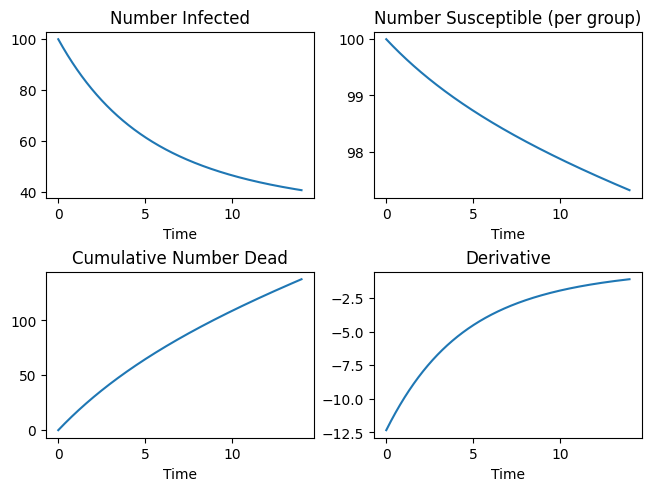

In [38]:
non_dec_c0_K_50.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.47053078 0.22139922 0.10417515 0.04901762 0.0230643
 0.01085246 0.00510642 0.00240273 0.00113056]
[1.00000000e+00 4.43910481e-01 1.97056518e-01 8.74754555e-02
 3.88312728e-02 1.72376098e-02 7.65195608e-03 3.39678373e-03
 1.50786802e-03 6.69358477e-04]
[1.00000000e+00 4.20146942e-01 1.76523456e-01 7.41657931e-02
 3.11605330e-02 1.30920037e-02 5.50056587e-03 2.31104620e-03
 9.70979131e-04 4.07953978e-04]
[1.00000000e+00 3.99107432e-01 1.59286748e-01 6.35725288e-02
 2.53722711e-02 1.01262633e-02 4.04146756e-03 1.61298004e-03
 6.43752464e-04 2.56926457e-04]
[1.00000000e+00 3.80577359e-01 1.44839133e-01 5.51224994e-02
 2.09783780e-02 7.98389712e-03 3.03849116e-03 1.15638125e-03
 4.40092658e-04 1.67489361e-04]
[1.00000000e+00 3.64305265e-01 1.32718334e-01 4.83499935e-02
 1.76141603e-02 6.41693286e-03 2.33772312e-03 8.51645143e-04
 3.10258938e-04 1.13029018e-04]
[1.00000

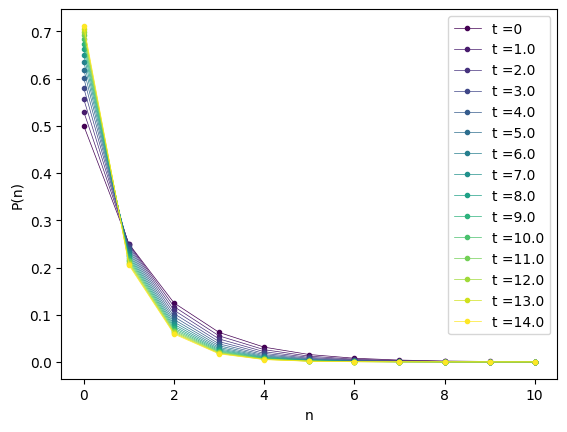

In [39]:
non_dec_c0_K_50.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 25

In [40]:
non_dec_c0_K_25 = new_run_model_for_K(25, new_c0 = 0.33, num_days = 14)

Steady state c0: 0.09381134507999148
Updated c0: 0.0033
1e-05
Error: 1.082655299349302e-15
0.9999983916326542 [0.69314718 0.        ] 0.9999983916326542 1.9999983916326398
Determinant: 8936.777636628058
Determinant: 8921.391636751649
Determinant: 8906.030861181884
Determinant: 8890.69527850443
Determinant: 8875.384857399877
Determinant: 8860.099566643114
Determinant: 8575.83075395549
Determinant: 8561.027254076065
Determinant: 8546.247992600009
Determinant: 8531.492939800626
0.09999999999999393
Error: 1.0664782543263156e-07
0.9840637736219578 [7.01211010e-01 5.76795125e-07] 0.9840637736219578 1.9840637734791635
Determinant: 8516.762066041898
Determinant: 8502.05534177792
Determinant: 8226.503402514605
Determinant: 8212.264117227181
Determinant: 8198.048119333249
Determinant: 8183.855380731176
Determinant: 8169.685873405715
Determinant: 8155.539569427693
Determinant: 8141.416440953387
Determinant: 7874.811581310305
0.20000000000005924
Error: 4.3681236428563344e-07
0.9684195885456757 [7.

In [41]:
non_dec_c0_K_25.states[7 * (10 ** 5) - 1]

np.float64(39.053143970207856)

In [42]:
non_dec_c0_K_25.states[7 * (10 ** 5) - 1]

np.float64(39.053143970207856)

In [43]:
non_dec_c0_K_25.states[-1]

np.float64(24.101820521949907)

In [44]:
non_dec_c0_K_25.num_dead[7 * (10 ** 5) - 1]

np.float64(72.94442399147053)

In [45]:
non_dec_c0_K_25.num_dead[-1]

np.float64(107.95044056311573)

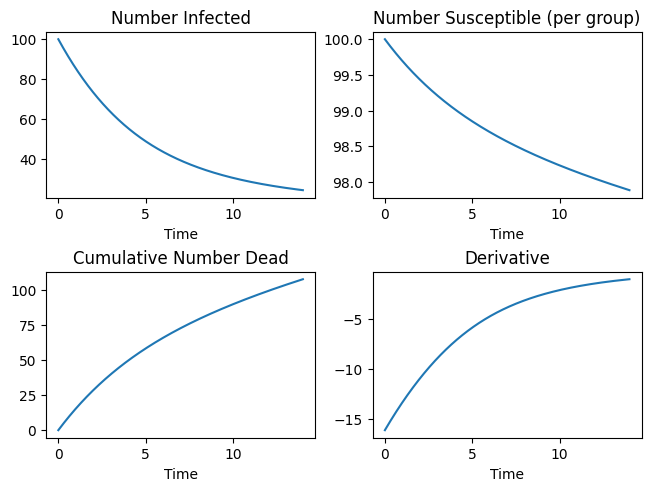

In [46]:
non_dec_c0_K_25.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.00000000e+00 4.60418471e-01 2.11985169e-01 9.76018876e-02
 4.49377121e-02 2.06901528e-02 9.52612859e-03 4.38600560e-03
 2.01939801e-03 9.29768155e-04]
[1.00000000e+00 4.22694699e-01 1.78670809e-01 7.55232045e-02
 3.19232587e-02 1.34937925e-02 5.70375468e-03 2.41094694e-03
 1.01909452e-03 4.30765870e-04]
[1.00000000e+00 3.87614481e-01 1.50244988e-01 5.82371344e-02
 2.25735575e-02 8.74983821e-03 3.39156421e-03 1.31461950e-03
 5.09565599e-04 1.97515025e-04]
[1.00000000e+00 3.55721309e-01 1.26537653e-01 4.50121418e-02
 1.60117792e-02 5.69573164e-03 2.02609337e-03 7.20724696e-04
 2.56377178e-04 9.11988438e-05]
[1.00000000e+00 3.27273483e-01 1.07107937e-01 3.50535909e-02
 1.14721123e-02 3.75451885e-03 1.22875474e-03 4.02138954e-04
 1.31609458e-04 4.30723015e-05]
[1.00000000e+00 3.02270086e-01 9.13672119e-02 2.76175792e-02
 8.34796992e-03 2.52334235e-03 7.62731195e-04 2.30550928e-0

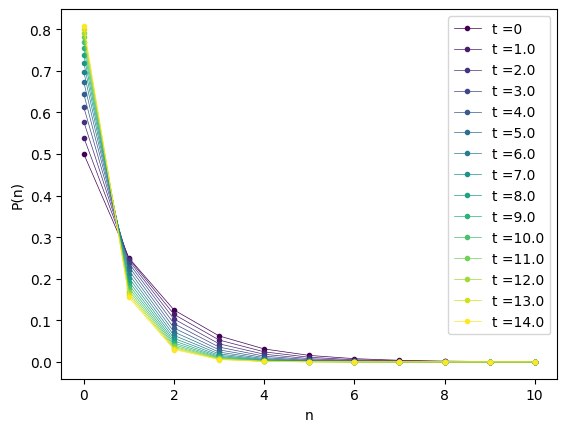

In [47]:
non_dec_c0_K_25.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 10

In [48]:
non_dec_c0_K_10 = new_run_model_for_K(10, new_c0 = 0.33, tau = 0.00001, num_days = 14)

Steady state c0: 37.86093900175134
Updated c0: 0.0033
1e-05
Error: 1.1088037039567546e-15
0.9999983331456714 [0.69314718 0.        ] 0.9999983331456714 1.9999983331456717
Determinant: 9103.255896388899
Determinant: 9088.104556624254
Determinant: 9072.978351911363
Determinant: 9057.87723967981
Determinant: 9042.801177424259
Determinant: 9027.750122704178
Determinant: 8743.6290212252
Determinant: 8729.075487578957
Determinant: 8714.546089252459
Determinant: 8700.040785295221
0.09999999999999393
Error: 1.0925270912906651e-07
0.9834696892653523 [7.01515401e-01 6.08844503e-07] 0.9834696892653523 1.9834696892649395
Determinant: 8685.559534818949
Determinant: 8671.102296997316
Determinant: 8395.604837340947
Determinant: 8381.629782139093
Determinant: 8367.6778945026
Determinant: 8353.749135047594
Determinant: 8339.843464449512
Determinant: 8325.960843443016
Determinant: 8058.881038908382
Determinant: 8045.465637286781
0.20000000000005924
Error: 4.4855051832373287e-07
0.9672127616610626 [7.099

In [49]:
non_dec_c0_K_10.states[7 * (10 ** 5) - 1]

np.float64(31.817744164600764)

In [50]:
non_dec_c0_K_10.states[-1]

np.float64(13.788411418402122)

In [51]:
non_dec_c0_K_10.num_dead[7 * (10 ** 5) - 1]

np.float64(69.04103582260525)

In [52]:
non_dec_c0_K_10.num_dead[-1]

np.float64(93.1603980858587)

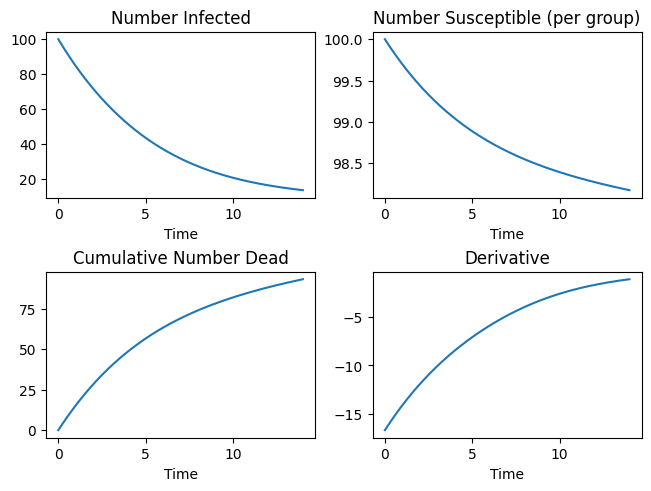

In [53]:
non_dec_c0_K_10.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.00000000e+00 4.58428377e-01 2.10156577e-01 9.63417383e-02
 4.41657867e-02 2.02468499e-02 9.28173054e-03 4.25500867e-03
 1.95061672e-03 8.94218055e-04]
[1.00000000e+00 4.17447231e-01 1.74262190e-01 7.27452688e-02
 3.03673110e-02 1.26767499e-02 5.29187414e-03 2.20907821e-03
 9.22173580e-04 3.84958808e-04]
[1.00000000e+00 3.77641125e-01 1.42612819e-01 5.38564655e-02
 2.03384163e-02 7.68062241e-03 2.90051889e-03 1.09535522e-03
 4.13651179e-04 1.56211697e-04]
[1.00000000e+00 3.39580904e-01 1.15315190e-01 3.91588366e-02
 1.32975932e-02 4.51560874e-03 1.53341451e-03 5.20718290e-04
 1.76825989e-04 6.00467300e-05]
[1.00000000e+00 3.03809946e-01 9.23004835e-02 2.80418052e-02
 8.51937943e-03 2.58827226e-03 7.86342873e-04 2.38898793e-04
 7.25798319e-05 2.20504757e-05]
[1.00000000e+00 2.70812467e-01 7.33393933e-02 1.98612226e-02
 5.37866690e-03 1.45661013e-03 3.94468211e-04 1.06826918e-0

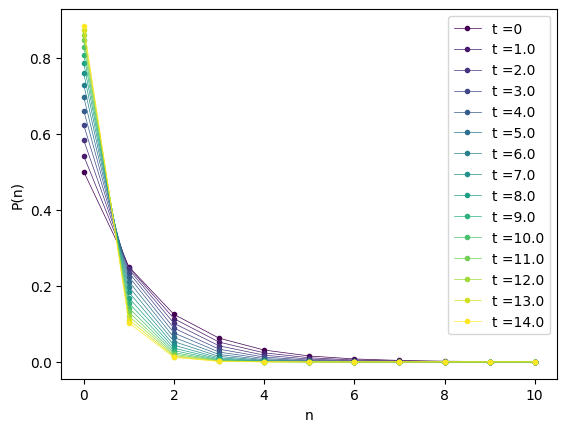

In [54]:
non_dec_c0_K_10.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = inf

In [56]:
non_dec_c0_K_inf = new_run_model_for_K_inf(tau = 0.00001, new_c0 = 0.33, num_days = 14)

Steady state c0: 0.001718213088854875
Updated c0: 0.0033
1e-05
Error: 5.529378285120863e-15
1.0000015350768223 [0.69314718 0.        ] 1.0000015350768223 2.000001535075281
Determinant: 3867.4087106379284
Determinant: 3873.9735062714662
Determinant: 3880.5495559356496
Determinant: 3887.136879077322
Determinant: 3893.735495176572
Determinant: 3900.3454237465444
Determinant: 3906.9666843337895
Determinant: 3913.5992965180017
Determinant: 3920.2432799123603
Determinant: 3926.8986541634026
0.09999999999999393
Error: 5.66499471990657e-07
1.0154584722955236 [6.85507080e-01 1.17743384e-06] 1.0154584722955236 2.015458456143666
Determinant: 3933.5654389510487
Determinant: 3940.243653988805
Determinant: 3946.933319023751
Determinant: 3953.6344538364997
Determinant: 3960.3470782413274
Determinant: 3967.0712120862786
Determinant: 3973.8068752531735
Determinant: 3980.5540876575487
Determinant: 3987.3128692488513
Determinant: 3994.0832400104528
0.20000000000005924
Error: 2.3082971374886237e-06
1.0311

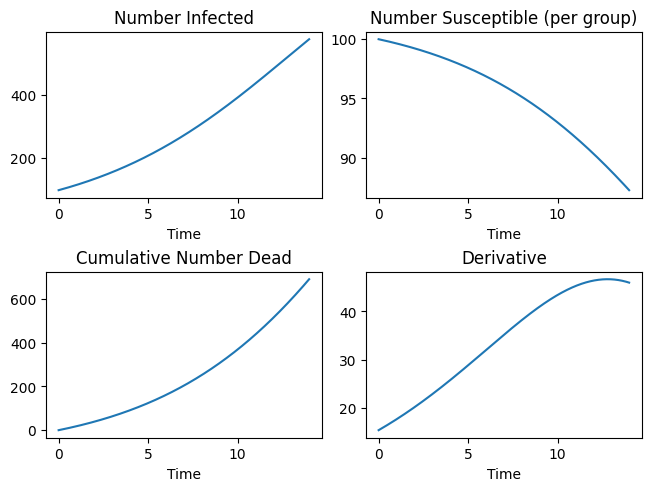

In [57]:
non_dec_c0_K_inf.graph_v2()

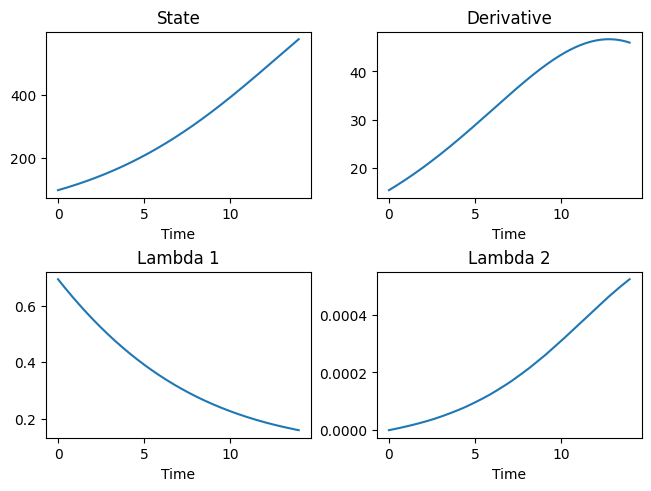

In [58]:
non_dec_c0_K_inf.graph()

In [59]:
non_dec_c0_K_inf.params

{'m_0': 100,
 'G': 100,
 'd_0': 0.16666666666666666,
 'c0': 0.0033,
 'c1': 1,
 'c2': 1,
 'tau': 1e-05,
 '<n>_(t-1)': np.float64(5.740294488416222),
 'm_(t-1)': np.float64(87.24451342122677),
 'h': 1,
 'I_(t-1)': np.float64(574.0289891271412)}

In [60]:
non_dec_c0_K_inf.lambdas[-1]

array([0.16044747, 0.00052269])

In [61]:
m_effective = non_dec_c0_K_inf.params['m_(t-1)'] - (
    non_dec_c0_K_inf.params['tau'] * 
    non_dec_c0_K_inf.params['c1'] * 
    non_dec_c0_K_inf.params['c0'] * 
    non_dec_c0_K_inf.params['m_(t-1)'] * 
    non_dec_c0_K_inf.params['<n>_(t-1)'])
Z = rf.R_mean(non_dec_c0_K_inf.func, non_dec_c0_K_inf.states[-1], m_effective, non_dec_c0_K_inf.params, non_dec_c0_K_inf.lambdas[-1])

In [62]:
m_effective, Z

(np.float64(87.24449689452318), np.float64(6.7443092132008875))

In [63]:
n_mean = rf.Rn_mean(non_dec_c0_K_inf.func, non_dec_c0_K_inf.states[-1], m_effective, non_dec_c0_K_inf.params, non_dec_c0_K_inf.lambdas[-1])/Z

In [64]:
n_mean

np.float64(5.745025130819703)

In [65]:
non_dec_c0_K_inf.states[-1]

np.float64(574.0294488416222)

In [66]:
n_mean * non_dec_c0_K_inf.params['G']

np.float64(574.5025130819703)

In [67]:
(non_dec_c0_K_inf.states[-1] - n_mean * non_dec_c0_K_inf.params['G']) ** 2

np.float64(0.22378977549611948)

In [68]:
# It's not lambdas being weird it's just straight up not being constrained

# Graphing stuff

In [69]:
list_of_models = [non_dec_c0_K_10,
                  non_dec_c0_K_25,
                  non_dec_c0_K_50,
                  non_dec_c0_K_100,
                  non_dec_c0_K_200,
                  non_dec_c0_K_400,
                  non_dec_c0_K_inf,]
labels = ["K = 10", "K = 25", "K = 50", "K = 100", "K = 200", "K = 400", "K = inf"]
K_vals = [10, 25, 50, 100, 200, 400]

K_cmap = plt.get_cmap('plasma')
K_norm = plt.Normalize(vmin=0, vmax=len(list_of_models))

/Users/meilinyen/Desktop/dymes_052026/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


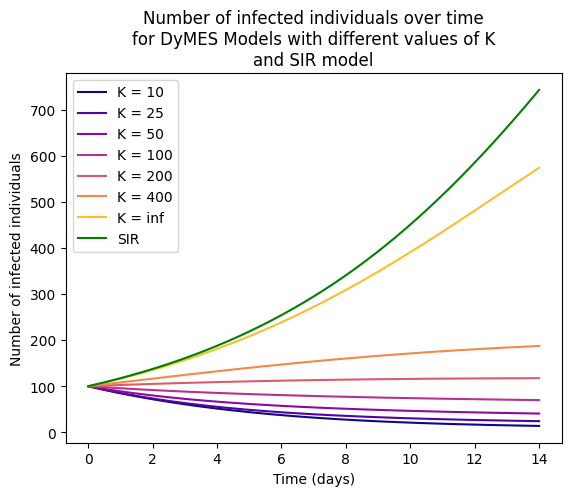

In [70]:
for i in range(len(list_of_models)):
  plt.plot(list_of_models[i].time,
           [list_of_models[i].states[j] for j in range(len(list_of_models[i].states))],
           label = labels[i],
           color = K_cmap(K_norm(i))
  )

plt.plot(
    sir_model_obj.t,
    [scaled_sir_vals[j] for j in range(len(scaled_sir_vals))],
    label = "SIR",
    color = 'green',
)

# plt.yscale('log')
plt.xlabel("Time (days)")
plt.ylabel("Number of infected individuals")
plt.title("Number of infected individuals over time\nfor DyMES Models with different values of K\nand SIR model")
plt.legend()
plt.show()
plt.show()

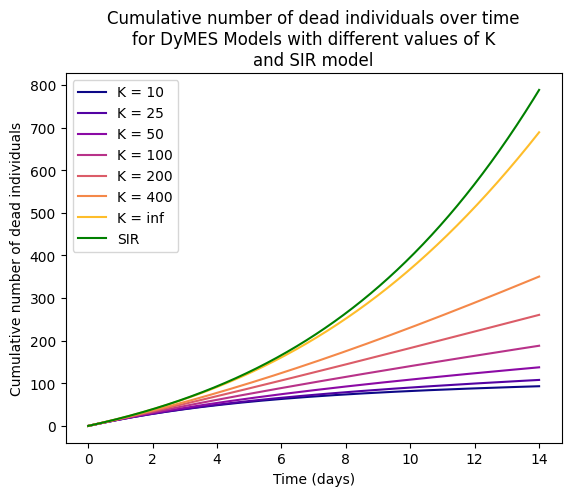

In [71]:
for i in range(len(list_of_models)):
  plt.plot(list_of_models[i].time,
           [list_of_models[i].num_dead[j] for j in range(len(list_of_models[i].num_dead))],
           label = labels[i],
           color = K_cmap(K_norm(i))
  )

plt.plot(
    sir_model_obj.t,
    [scaled_sir_dead[j] for j in range(len(scaled_sir_dead))],
    label = "SIR",
    color = 'green',
)

# plt.yscale('log')
plt.xlabel("Time (days)")
plt.ylabel("Cumulative number of dead individuals")
plt.title("Cumulative number of dead individuals over time\nfor DyMES Models with different values of K\nand SIR model")
plt.legend()
plt.show()

In [73]:
x_upper_bound = 10

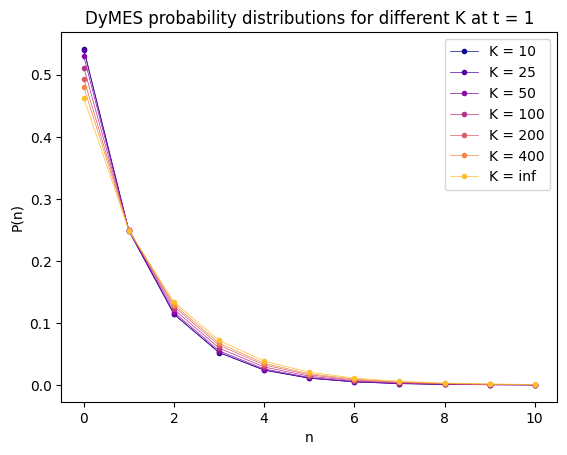

In [74]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[1.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           normalized_pd[0:x_upper_bound+1],
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("P(n)")
plt.title("DyMES probability distributions for different K at t = 1")
plt.legend()
plt.show()

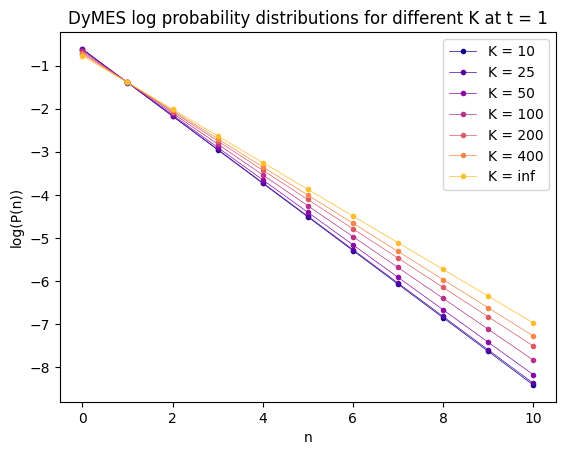

In [75]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[1.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 1")
plt.legend()
plt.show()

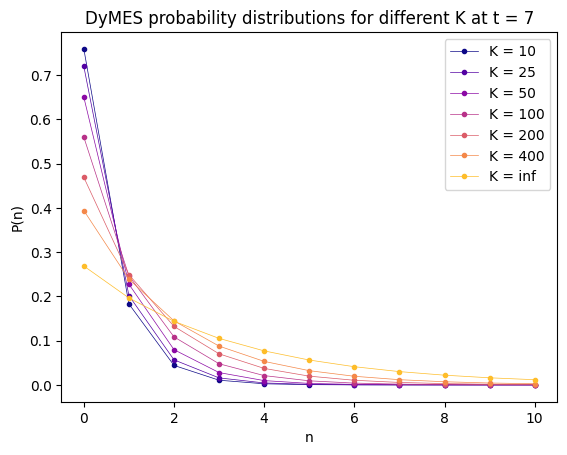

In [76]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[7.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           normalized_pd[0:x_upper_bound+1],
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("P(n)")
plt.title("DyMES probability distributions for different K at t = 7")
plt.legend()
plt.show()

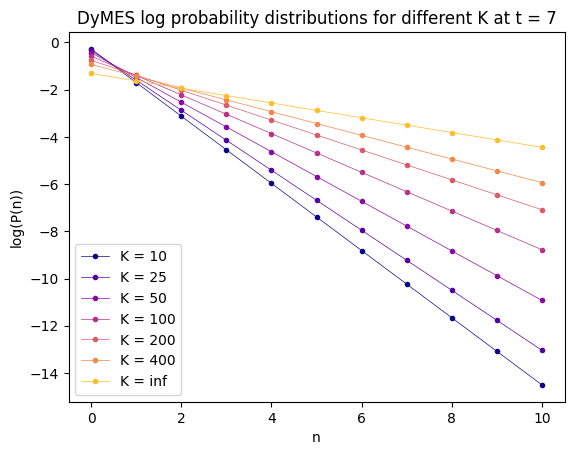

In [77]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[7.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 7")
plt.legend()
plt.show()

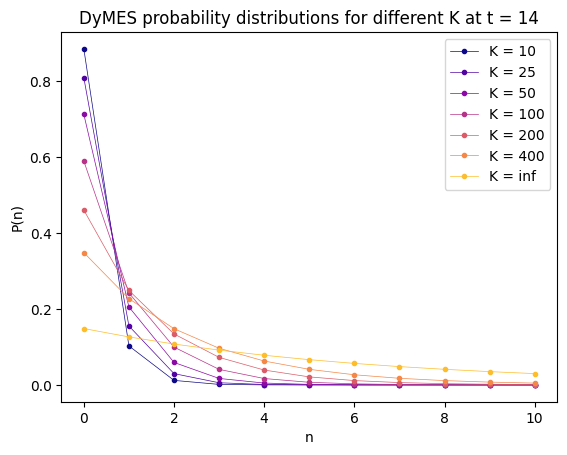

In [78]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[14.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           normalized_pd[0:x_upper_bound+1],
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("P(n)")
plt.title("DyMES probability distributions for different K at t = 14")
plt.legend()
plt.show()

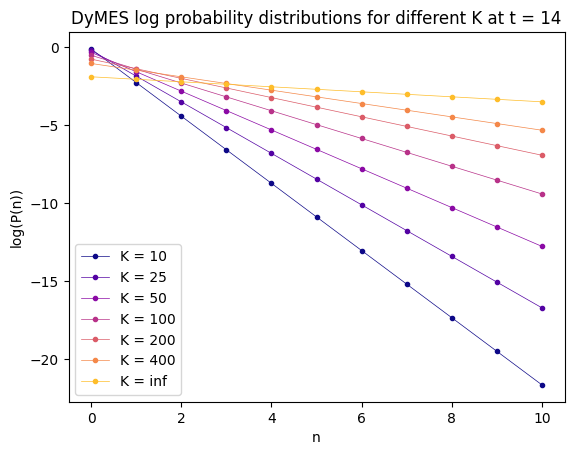

In [79]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[14.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 14")
plt.legend()
plt.show()

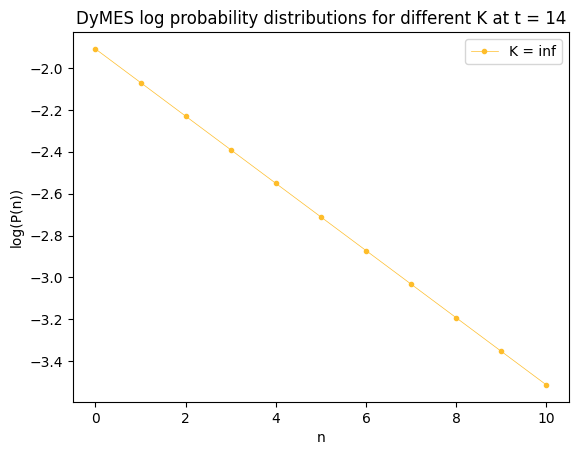

In [80]:
for i in range(len(list_of_models)-1, len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[14.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 14")
plt.legend()
plt.show()